In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/creditcard_preprocessed.csv")
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time,PCA1,PCA2
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583,-1.571678,0.675572
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583,1.086213,0.282673
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562,-2.053411,-1.077634
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562,-1.150107,0.427442
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541,-1.143820,1.341999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,-0.509348,1.436807,0.250034,0.943651,0.823731,0,-0.350151,1.641931,-9.657134,9.457475
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,-0.254117,1.641952,-0.467720,0.602071
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,-0.081839,1.641974,1.998489,-1.216424
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.123205,-0.569159,0.546668,0.108821,0.104533,0,-0.313249,1.641974,0.040759,0.604718


In [2]:
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
x_train, y_train = joblib.load("../data/processed/x_train_smote.pkl"), joblib.load("../data/processed/y_train_smote.pkl")
x_test, y_test = joblib.load("../data/processed/x_test.pkl"), joblib.load("../data/processed/y_test.pkl")

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (454902, 32) (454902,)
Test: (56962, 32) (56962,)


In [4]:
log_reg = LogisticRegression(max_iter=500, solver='lbfgs')

log_reg.fit(x_train, y_train)

y_pred_lr = log_reg.predict(x_test)
y_pred_proba_lr = log_reg.predict_proba(x_test)[: 1]

print("LODISTIC REGRESSION REPORT")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

LODISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9466889492150264


In [5]:
rf = RandomForestClassifier(
    n_estimators=80, 
    max_depth=12, 
    min_samples_split=5,
    min_samples_leaf=2, 
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_pred_proba_rf = rf.predict_proba(x_test)[:, 1]

print("RANDON FOREST REPORT")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))

RANDON FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.87      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9782220270634985


In [6]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_pred_proba_xgb = xgb.predict_proba(x_test)[:, 1]

print("XGBOOST REPORT")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))

XGBOOST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.89      0.72        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9789086815086192


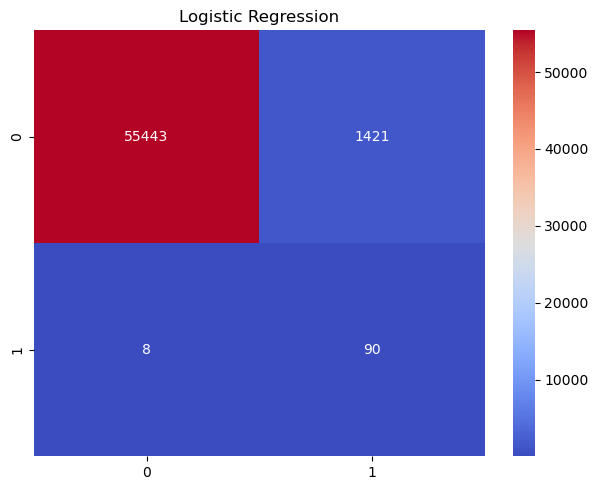

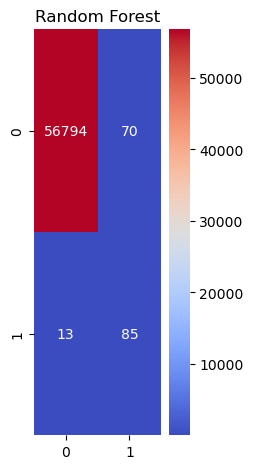

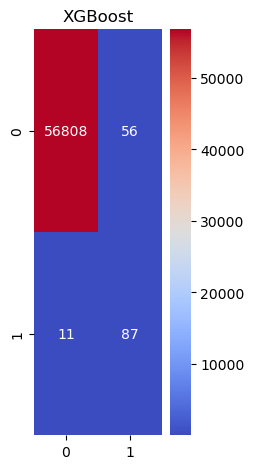

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": confusion_matrix(y_test, y_pred_lr),
    "Random Forest": confusion_matrix(y_test, y_pred_rf),
    "XGBoost": confusion_matrix(y_test, y_pred_xgb)
}

plt.figure(figsize=(18, 5))
i = 1
for name, cm in models.items():
    plt.subplot(1,3,i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
    plt.title(name)
    i += 1

    plt.tight_layout()
    plt.show()

In [8]:
joblib.dump(log_reg, "../models/logistic_regression.pkl")
joblib.dump(rf, "../models/randum_forest.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")

print("All models saved successfully!")

All models saved successfully!
